## <u>Import Libraries</u>

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

---
## <u>Generate Synthetic Dataset</u>

Using `make_regression` instead of a real dataset (powerplant, UFC, etc.) so the comparison isolates **model differences**, not data quirks -- every source of noise, informativeness, and feature redundancy is fully controlled, so any performance gap between models is attributable to the models themselves, not a hidden data ceiling.

- `n_informative=12` of `20` total features actually drive `y` -- the other 8 are pure noise, testing whether each model can ignore irrelevant features.
- `noise=45` adds random scatter around the true relationship.

**Note:** this is higher than the `noise=8` range discussed earlier as a starting point -- worth confirming this is intentional before treating results as final, since it meaningfully affects how hard the problem is for every model.

In [2]:
X, y = make_regression(
    n_samples=100000,
    n_features=20,
    n_informative=12,
    noise=45,
    random_state=42
)
X = pd.DataFrame(X)

---
## <u>Train Test Split</u>

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

---
## <u>Scale Features</u>

In [4]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## <u>Convert to PyTorch Tensors</u>

Already numeric, no pandas dtype gotchas here (no booleans, no categoricals) -- `.values` is safe.

In [5]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

---
## <u>Build TensorDataset & DataLoader</u>

In [6]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

---
## <u>Define ANN Model</u>

**Worth flagging -- this architecture widens going deeper (`64 -> 128 -> 256`) rather than tapering down toward the output.** Every prior build (regression and classification alike) followed the opposite convention -- start near the input size, shrink toward the output, since each layer's job is to compress the previous layer's representation. Growing wider before the final `Linear(256,1)` isn't necessarily broken, but it's a real deviation from the pattern used everywhere else so far, and it meaningfully increases parameter count (and therefore overfitting risk) versus a tapering equivalent. Worth an experiment: compare against a tapering version (e.g. `256 -> 128 -> 64 -> 1`) once this one has a baseline result.

In [7]:
class ANN_Regression(nn.Module):

    def __init__(self):
        super(ANN_Regression, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train_tensor.shape[1], 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

---
## <u>Compile the Model</u>

In [8]:
model = ANN_Regression()

loss_func = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

---
## <u>Train the Model</u>

In [9]:
epochs = 50
train_loss_history = []
val_loss_history = []
best_val_loss = float("inf")
best_epoch = 1

for epoch in range(epochs):

    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        y_pred_tensor = model(x_batch)
        batch_loss = loss_func(y_pred_tensor, y_batch)
        batch_loss.backward()
        optimizer.step()

        total_train_loss = total_train_loss + batch_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            y_pred_tensor = model(x_batch)
            batch_loss = loss_func(y_pred_tensor, y_batch)

            total_val_loss = total_val_loss + batch_loss.item()

    avg_val_loss = total_val_loss / len(test_loader)
    val_loss_history.append(avg_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {avg_train_loss} & val loss = {avg_val_loss}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_regression_model.pt")

print("best model at epoch : ", best_epoch)

epoch 1/50 ==> train loss = 2852.970837426758 & val loss = 2083.6512755859376
epoch 2/50 ==> train loss = 2105.1433423828125 & val loss = 2112.563017285156
epoch 3/50 ==> train loss = 2086.3436962890623 & val loss = 2089.0656146484375
epoch 4/50 ==> train loss = 2076.1243575195313 & val loss = 2090.431815625
epoch 5/50 ==> train loss = 2064.9628423339846 & val loss = 2127.270613671875
epoch 6/50 ==> train loss = 2060.915203149414 & val loss = 2130.3777083984373
epoch 7/50 ==> train loss = 2054.1581193359375 & val loss = 2101.6345173828126
epoch 8/50 ==> train loss = 2049.8818189453127 & val loss = 2075.3272749023436
epoch 9/50 ==> train loss = 2038.2904200439452 & val loss = 2094.4157041015624
epoch 10/50 ==> train loss = 2038.5026582763671 & val loss = 2096.1370458007814
epoch 11/50 ==> train loss = 2033.2903341552735 & val loss = 2077.1100044921877
epoch 12/50 ==> train loss = 2027.3955169433593 & val loss = 2094.461387109375
epoch 13/50 ==> train loss = 2020.9983434326173 & val loss

---
## <u>Plot ANN Loss Curves</u>

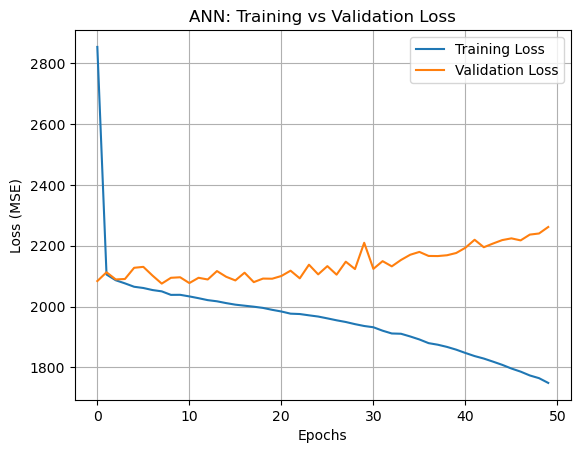

In [10]:
loss_df = pd.DataFrame({
    "Training Loss": train_loss_history,
    "Validation Loss": val_loss_history
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("ANN: Training vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

---
## <u>Load Best Checkpoint & Evaluate ANN</u>

In [11]:
model.load_state_dict(torch.load("best_regression_model.pt", weights_only=True))
model.eval()

with torch.no_grad():
    y_train_pred = model(X_train_tensor)
    y_test_pred = model(X_test_tensor)

    train_mse_loss = loss_func(y_train_pred, y_train_tensor)
    test_mse_loss = loss_func(y_test_pred, y_test_tensor)

    r2_train_ann = r2_score(y_train_tensor.numpy(), y_train_pred.numpy())
    r2_test_ann = r2_score(y_test_tensor.numpy(), y_test_pred.numpy())

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())
print("r^2 score for training =", r2_train_ann)
print("r^2 score for testing =", r2_test_ann)

Training MSE: 2006.1234130859375
Testing MSE: 2075.327392578125
r^2 score for training = 0.9355034232139587
r^2 score for testing = 0.9341155886650085


---
## <u>Linear Regression</u>

In [12]:
lnr = LinearRegression()
lnr.fit(X_train_scaled, y_train)

y_test_pred_lnr = lnr.predict(X_test_scaled)
r2_test_lnr = r2_score(y_test, y_test_pred_lnr)

print("--- Linear Regression ---")
print("r^2 score for testing =", r2_test_lnr)

--- Linear Regression ---
r^2 score for testing = 0.9356558629573822


---
## <u>Random Forest Regressor</u>

In [13]:
rf = RandomForestRegressor(n_estimators=201, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_test_pred_rf = rf.predict(X_test_scaled)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("--- Random Forest ---")
print("r^2 score for testing =", r2_test_rf)

--- Random Forest ---
r^2 score for testing = 0.6608820568152728


---
## <u>Gradient Boosting Regressor</u>


In [14]:
gbr = GradientBoostingRegressor(n_estimators=201, max_depth=3, random_state=42)
gbr.fit(X_train_scaled, y_train)

y_test_pred_gbr = gbr.predict(X_test_scaled)
r2_test_gbr = r2_score(y_test, y_test_pred_gbr)

print("--- Gradient Boosting ---")
print("r^2 score for testing =", r2_test_gbr)

--- Gradient Boosting ---
r^2 score for testing = 0.9207441379957186


---
## <u>Report — Findings Summary</u>

See `ANN_vs_ML_Regression_Report.md` for the full write-up. Quick summary table:

| Model | Test R² |
|---|---|
| Linear Regression | 0.936 |
| Random Forest (depth=8) | 0.661 |
| Gradient Boosting (depth=3) | 0.921 |
| ANN (64→128→256→1) | 0.93 |